In [1]:
!nvidia-smi

Tue Jun 23 04:42:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   44C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# !git clone https://github.com/Omid-Nejati/Locality-iN-Locality.git

!git clone https://github.com/huongng389/Locality-iN-Locality.git

Cloning into 'Locality-iN-Locality'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 75 (delta 25), reused 26 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 5.27 MiB | 23.54 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [3]:
cd /content/Locality-iN-Locality

/content/Locality-iN-Locality


In [4]:
pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 19.5 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: re

In [5]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary

In [6]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [7]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  1330k      0  0:03:22  0:03:22 --:--:--  711k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  10.9M      0  0:00:07  0:00:07 --:--:-- 17.1M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0  86763      0  0:00:01  0:00:01 --:--:-- 86777


In [8]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [9]:
import shutil

In [10]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]


  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [11]:
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7)
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)

#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]


In [12]:
batch_size = 10

trainset = torchvision.datasets.ImageFolder(root='./data/GTSRB/Final_Training/Images',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

# batch_size = 32

# trainset = torchvision.datasets.ImageFolder(
#     root='./data/GTSRB/Final_Training/Images',
#     transform=transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.RandomApply([
#             transforms.RandomAffine(
#                 degrees=12,
#                 translate=(0.05, 0.05),
#                 scale=(0.9, 1.1),
#                 shear=6,
#             )
#         ], p=0.6),
#         transforms.RandomPerspective(distortion_scale=0.18, p=0.25),
#         transforms.ColorJitter(
#             brightness=0.30,
#             contrast=0.30,
#             saturation=0.20,
#             hue=0.03,
#         ),
#         transforms.RandomApply([
#             transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
#         ], p=0.12),
#         transforms.ToTensor(),
#         transforms.RandomErasing(
#             p=0.12,
#             scale=(0.01, 0.05),
#             ratio=(0.3, 3.3),
#             value='random',
#         ),
#     ])
# )

# testset = torchvision.datasets.ImageFolder(
#     root='./data/GTSRB/test',
#     transform=transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#     ])
# )

# train_loader = torch.utils.data.DataLoader(
#     dataset=trainset,
#     batch_size=batch_size,
#     shuffle=True,
#     num_workers=2,
#     pin_memory=True,
# )

# test_loader = torch.utils.data.DataLoader(
#     dataset=testset,
#     batch_size=batch_size * 2,
#     shuffle=False,
#     num_workers=2,
#     pin_memory=True,
# )

In [13]:
batch = next(iter(train_loader))
train_data = batch[0]

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

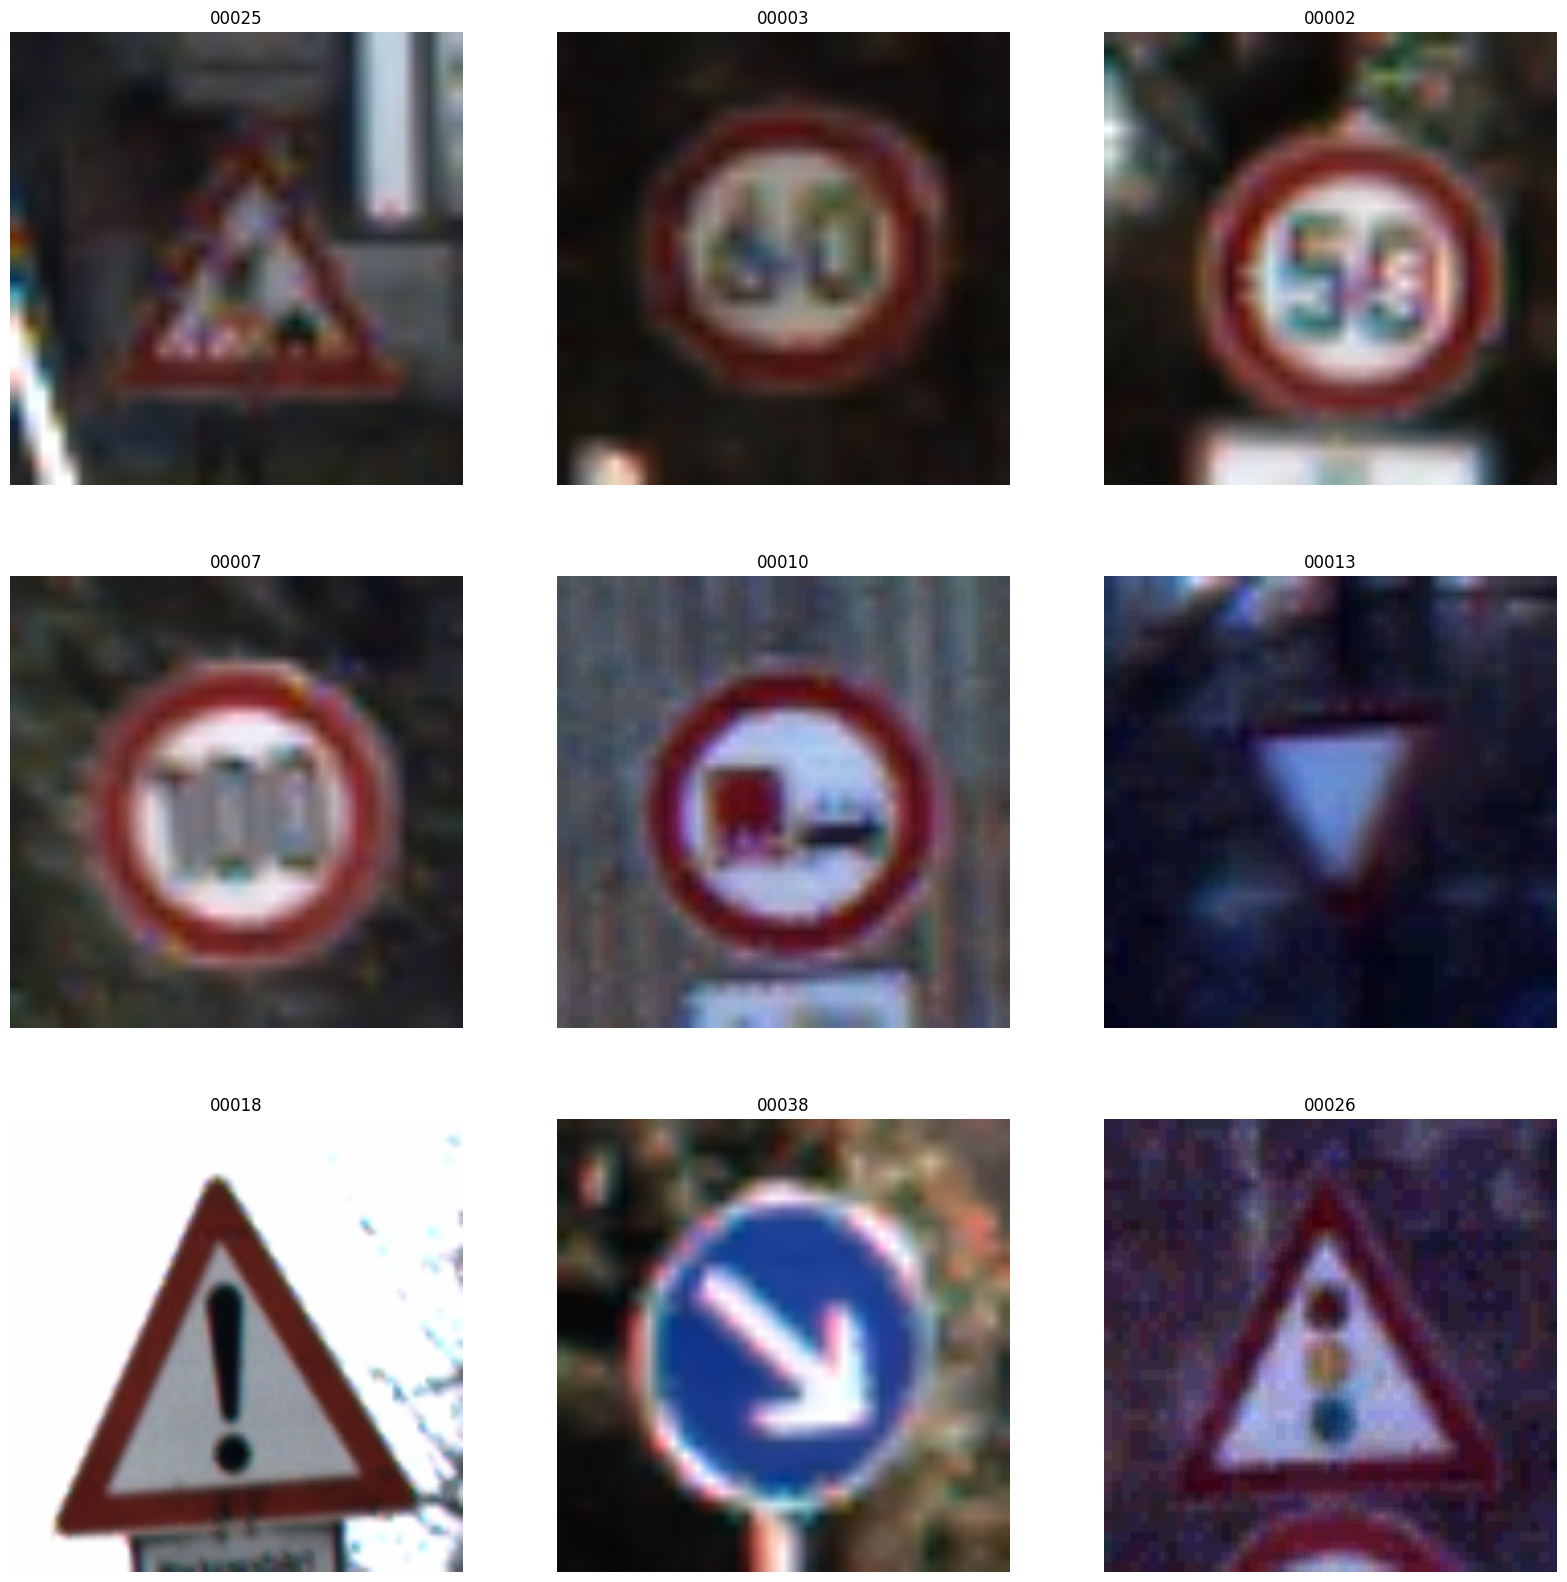

In [15]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [16]:
pip install timm

In [17]:
pip install einops

In [18]:
# from LNL import LNL_Ti as small

from LNL_TS import LNL_Ti as small

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/content/Locality-iN-Locality/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered

In [19]:
model = small(pretrained=False)

In [20]:
model.head

Linear(in_features=192, out_features=43, bias=True)

In [21]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [22]:
model = model.cuda()

## Train Locality-iN-Locality

In [23]:
num_epochs = 25

In [24]:
# loss = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

loss = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-2,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
)

In [25]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.cuda()
        Y = batch_labels.cuda()

        pre = model(X)
        cost = loss(pre, Y)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

    scheduler.step()

Epoch [1/25], lter [200/3920], Loss: 2.751777
Epoch [1/25], lter [400/3920], Loss: 2.347154
Epoch [1/25], lter [600/3920], Loss: 1.354524
Epoch [1/25], lter [800/3920], Loss: 1.089587
Epoch [1/25], lter [1000/3920], Loss: 1.177058
Epoch [1/25], lter [1200/3920], Loss: 0.658014
Epoch [1/25], lter [1400/3920], Loss: 0.836197
Epoch [1/25], lter [1600/3920], Loss: 0.481466
Epoch [1/25], lter [1800/3920], Loss: 0.579734
Epoch [1/25], lter [2000/3920], Loss: 0.412916
Epoch [1/25], lter [2200/3920], Loss: 0.428613
Epoch [1/25], lter [2400/3920], Loss: 0.417420
Epoch [1/25], lter [2600/3920], Loss: 0.478759
Epoch [1/25], lter [2800/3920], Loss: 0.435722
Epoch [1/25], lter [3000/3920], Loss: 0.413961
Epoch [1/25], lter [3200/3920], Loss: 0.420124
Epoch [1/25], lter [3400/3920], Loss: 0.441292
Epoch [1/25], lter [3600/3920], Loss: 0.441957
Epoch [1/25], lter [3800/3920], Loss: 0.404083
Epoch [2/25], lter [200/3920], Loss: 0.436473
Epoch [2/25], lter [400/3920], Loss: 0.393832
Epoch [2/25], lter 

## Test

In [26]:
model.eval()
correct = 0
total = 0

for images, labels in test_loader:

    images = images.cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 99.24 %


## FGSM attack

In [27]:
model.eval()

correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 89.15 %


## PGD attack

In [28]:
model.eval()

correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 54.79 %


## Save pretrained model for submission

Run this after training the selected model. The saved `.pth` file is the pretrained model submitted with `LNL_TS.py`.


In [ ]:
import os

os.makedirs('pretrained', exist_ok=True)
torch.save(model.state_dict(), 'pretrained/lnl_ts_ti_gtsrb.pth')
print('Saved pretrained model to pretrained/lnl_ts_ti_gtsrb.pth')

import shutil
from google.colab import files

shutil.make_archive('/content/data', 'zip', '/content/Locality-iN-Locality/data')
shutil.make_archive('/content/pretrained', 'zip', '/content/Locality-iN-Locality/pretrained')

# files.download('/content/data.zip')
files.download('/content/pretrained.zip')

## Verify plug-and-play pretrained loading

This is the minimal checker code: same model file, local pretrained weights, then the original evaluation loop can be reused.


In [ ]:
from LNL_TS import LNL_Ti as small

model = small(pretrained=True)
model = model.cuda()
model.eval()
print('Loaded pretrained LNL-TS model successfully')

 ## Print top-1 and top-5: LNL_Ti

In [ ]:
from LNL_TS import LNL_Ti as small
import torch

test_loader = torch.utils.data.DataLoader(
    dataset=testset,
    batch_size=batch_size * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

model = small(pretrained=True)
model = model.cuda()
model.eval()

correct_1 = 0
correct_5 = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)

        # Top-1 accuracy
        predicted_1 = outputs.argmax(dim=1)
        correct_1 += predicted_1.eq(labels).sum().item()

        # Top-5 accuracy
        _, predicted_5 = outputs.topk(5, 1, True, True)
        correct_5 += (predicted_5 == labels.view(-1, 1)).sum().item()

        total += labels.size(0)

print('Reloaded pretrained Top-1 accuracy: %.2f %%' % (100.0 * correct_1 / total))
print('Reloaded pretrained Top-5 accuracy: %.2f %%' % (100.0 * correct_5 / total))

### Train LNL-MoEx

In [29]:
# from LNL_MoEx import LNL_MoEx_Ti as small
from LNL_TS import LNL_MoEx_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [30]:
model = model.cuda()

In [31]:
import time
# time.clock_gettime()

In [32]:
num_epochs = 25
moex_lam = .9
moex_prob = .7

In [33]:
# loss = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

loss = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-2,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
)

In [34]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (input, target) in enumerate(train_loader):
        input = input.cuda()
        target = target.cuda()

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]
            output = model(input, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss(output, target_a) * lam + loss(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model(input)
            # if args.prof >= 0: torch.cuda.nvtx.range_pop()
            cost = loss(output, target)

        # compute gradient and do SGD step

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

    scheduler.step()

Epoch [1/25], lter [200/3920], Loss: 3.321390
Epoch [1/25], lter [400/3920], Loss: 3.184607
Epoch [1/25], lter [600/3920], Loss: 2.451766
Epoch [1/25], lter [800/3920], Loss: 1.202386
Epoch [1/25], lter [1000/3920], Loss: 1.254067
Epoch [1/25], lter [1200/3920], Loss: 0.953784
Epoch [1/25], lter [1400/3920], Loss: 0.613823
Epoch [1/25], lter [1600/3920], Loss: 1.024621
Epoch [1/25], lter [1800/3920], Loss: 1.058605
Epoch [1/25], lter [2000/3920], Loss: 1.042936
Epoch [1/25], lter [2200/3920], Loss: 0.416955
Epoch [1/25], lter [2400/3920], Loss: 0.813535
Epoch [1/25], lter [2600/3920], Loss: 0.901116
Epoch [1/25], lter [2800/3920], Loss: 0.956376
Epoch [1/25], lter [3000/3920], Loss: 1.230271
Epoch [1/25], lter [3200/3920], Loss: 0.943515
Epoch [1/25], lter [3400/3920], Loss: 0.425028
Epoch [1/25], lter [3600/3920], Loss: 0.908311
Epoch [1/25], lter [3800/3920], Loss: 0.838038
Epoch [2/25], lter [200/3920], Loss: 0.802227
Epoch [2/25], lter [400/3920], Loss: 0.948126
Epoch [2/25], lter 

### Test

In [41]:
model.eval()
correct = 0
total = 0

for images, labels in test_loader:

    images = images.cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 98.67 %


### FGSM attack

In [42]:
model.eval()
correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy (FGSM): %.2f %%' % (100 * float(correct) / total))

Robust accuracy (FGSM): 68.05 %


### PGD attack

In [43]:
model.eval()
correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy (PGD): %.2f %%' % (100 * float(correct) / total))

Robust accuracy (PGD): 32.15 %


### Save pretrained model for submission

Run this after training the selected model. The saved `.pth` file is the pretrained model submitted with `LNL_TS.py`.


In [35]:
import os

os.makedirs('pretrained', exist_ok=True)
torch.save(model.state_dict(), 'pretrained/lnl_ts_moex_ti_gtsrb.pth')
print('Saved pretrained model to pretrained/lnl_ts_moex_ti_gtsrb.pth')

import shutil
from google.colab import files

shutil.make_archive('/content/data', 'zip', '/content/Locality-iN-Locality/data')
shutil.make_archive('/content/pretrained', 'zip', '/content/Locality-iN-Locality/pretrained')

# files.download('/content/data.zip')
files.download('/content/pretrained.zip')

Saved pretrained model to pretrained/lnl_ts_ti_gtsrb.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Verify plug-and-play pretrained loading

This is the minimal checker code: same model file, local pretrained weights, then the original evaluation loop can be reused.


In [36]:
from LNL_TS import LNL_MoEx_Ti as small

model = small(pretrained=True)
model = model.cuda()
model.eval()
print('Loaded pretrained LNL-TS model successfully')

Loaded pretrained LNL-TS model successfully


 ### Print top-1 and top-5: LNL_MoEx_Ti

In [44]:
from LNL_TS import LNL_MoEx_Ti as small
import torch

test_loader = torch.utils.data.DataLoader(
    dataset=testset,
    batch_size=batch_size * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

model = small(pretrained=True)
model = model.cuda()
model.eval()

correct_1 = 0
correct_5 = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda()
        labels = labels.cuda()

        outputs = model(images)

        # Top-1 accuracy
        predicted_1 = outputs.argmax(dim=1)
        correct_1 += predicted_1.eq(labels).sum().item()

        # Top-5 accuracy
        _, predicted_5 = outputs.topk(5, 1, True, True)
        correct_5 += (predicted_5 == labels.view(-1, 1)).sum().item()

        total += labels.size(0)

print('Reloaded pretrained Top-1 accuracy: %.2f %%' % (100.0 * correct_1 / total))
print('Reloaded pretrained Top-5 accuracy: %.2f %%' % (100.0 * correct_5 / total))

Reloaded pretrained Top-1 accuracy: 98.67 %
Reloaded pretrained Top-5 accuracy: 99.73 %


## Number of Parameters

In [38]:
pip install ptflops

In [39]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

  Cloning https://github.com/sovrasov/flops-counter.pytorch.git to /tmp/pip-req-build-8ck5k3_4
  Running command git clone --filter=blob:none --quiet https://github.com/sovrasov/flops-counter.pytorch.git /tmp/pip-req-build-8ck5k3_4
  Resolved https://github.com/sovrasov/flops-counter.pytorch.git to commit d612c7547445841a325fd2a1ff2ab27583f01bae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ptflops: filename=ptflops-0.7.6-py3-none-any.whl size=19501 sha256=43bf53a5826de19e22efd343202a6514b437a07b8697129f7138654fc5f00e99
  Stored in directory: /tmp/pip-ephem-wheel-cache-l62t_f75/wheels/c3/60/94/c0a4677f6c1ff199ef7a6717fa47797ea51309624895931fe9
Successfully built ptflops
  Attempting uninstall: ptflops
    Found existing installation: ptflops 0.7.5
    Uninstalling ptflops-0.7.5:
      Successfully uninstalled ptflops-0.7.5


In [40]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))


TrafficSignLNL(
  6.04 M, 99.371% Params, 1.25 GMac, 99.682% MACs, 
  (pixel_embed): PixelEmbed(
    1.27 k, 0.021% Params, 10.91 MMac, 0.871% MACs, 
    (proj): TrafficSignStem(
      1.27 k, 0.021% Params, 10.91 MMac, 0.871% MACs, 
      (conv1): Conv2d(648, 0.011% Params, 8.13 MMac, 0.649% MACs, 3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(48, 0.001% Params, 602.11 KMac, 0.048% MACs, 24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): GELU(0, 0.000% Params, 301.06 KMac, 0.024% MACs, approximate='none')
      (dwconv): Conv2d(216, 0.004% Params, 677.38 KMac, 0.054% MACs, 24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
      (bn2): BatchNorm2d(48, 0.001% Params, 150.53 KMac, 0.012% MACs, 24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): GELU(0, 0.000% Params, 75.26 KMac, 0.006% MACs, approximate='none')
      (pwconv): Conv2d(288, 0.005% Par

## Fine-tune current best LNL-TS toward 99.5%+

This section continues from the current best non-MoEx checkpoint (`99.24%` in this notebook). It uses mild augmentation, low learning rate, EMA, and deterministic multi-scale TTA for checkpoint selection. Save the best model as `pretrained/lnl_ts_ti_gtsrb_finetuned.pth`.


In [ ]:
import copy
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode

from LNL_TS import LNL_Ti as small

os.makedirs('pretrained', exist_ok=True)

finetune_train_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=5,
            translate=(0.02, 0.02),
            scale=(0.96, 1.04),
            shear=2,
            interpolation=InterpolationMode.BILINEAR,
        )
    ], p=0.35),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.01),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
])

def tta_transform(image):
    to_tensor = transforms.ToTensor()
    crops = []
    for resize_size in (224, 240, 256):
        resized = transforms.Resize((resize_size, resize_size), interpolation=InterpolationMode.BICUBIC)(image)
        if resize_size == 224:
            crops.append(to_tensor(resized))
        else:
            crops.extend(to_tensor(crop) for crop in transforms.FiveCrop(224)(resized))
    return torch.stack(crops)

finetune_trainset = torchvision.datasets.ImageFolder(
    root='./data/GTSRB/Final_Training/Images',
    transform=finetune_train_transform,
)
clean_testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test', transform=eval_transform)
tta_testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test', transform=tta_transform)

finetune_batch_size = 32
finetune_train_loader = torch.utils.data.DataLoader(
    finetune_trainset, batch_size=finetune_batch_size, shuffle=True, num_workers=2, pin_memory=True
)
clean_test_loader = torch.utils.data.DataLoader(
    clean_testset, batch_size=finetune_batch_size * 2, shuffle=False, num_workers=2, pin_memory=True
)
tta_test_loader = torch.utils.data.DataLoader(
    tta_testset, batch_size=finetune_batch_size, shuffle=False, num_workers=2, pin_memory=True
)

print('Fine-tune train/test sizes:', len(finetune_trainset), len(clean_testset))


In [ ]:
class ModelEma:
    def __init__(self, model, decay=0.9995):
        self.module = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        ema_state = self.module.state_dict()
        model_state = model.state_dict()
        for key, value in ema_state.items():
            model_value = model_state[key].detach()
            if value.dtype.is_floating_point:
                value.mul_(self.decay).add_(model_value, alpha=1.0 - self.decay)
            else:
                value.copy_(model_value)

@torch.no_grad()
def evaluate_topk(model, loader, use_tta=False):
    model.eval()
    correct_1 = 0
    correct_5 = 0
    total = 0
    for images, labels in loader:
        labels = labels.cuda(non_blocking=True)
        if use_tta:
            b, crops, c, h, w = images.shape
            images = images.view(b * crops, c, h, w).cuda(non_blocking=True)
            outputs = model(images).view(b, crops, -1).mean(dim=1)
        else:
            images = images.cuda(non_blocking=True)
            outputs = model(images)
        pred_1 = outputs.argmax(dim=1)
        _, pred_5 = outputs.topk(5, 1, True, True)
        total += labels.size(0)
        correct_1 += pred_1.eq(labels).sum().item()
        correct_5 += (pred_5 == labels.view(-1, 1)).sum().item()
    return 100.0 * correct_1 / total, 100.0 * correct_5 / total


In [ ]:
model = small(pretrained=True).cuda()
ema = ModelEma(model, decay=0.9995)

criterion = nn.CrossEntropyLoss(label_smoothing=0.02)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=2e-2)
num_finetune_epochs = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_finetune_epochs)
scaler = torch.cuda.amp.GradScaler()

best_tta_top1 = 0.0
best_clean_top1 = 0.0
best_state = None

for epoch in range(num_finetune_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in finetune_train_loader:
        images = images.cuda(non_blocking=True)
        labels = labels.cuda(non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss_value = criterion(outputs, labels)
        scaler.scale(loss_value).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)
        running_loss += loss_value.item() * labels.size(0)

    scheduler.step()
    train_loss = running_loss / len(finetune_trainset)
    clean_top1, clean_top5 = evaluate_topk(ema.module, clean_test_loader, use_tta=False)
    tta_top1, tta_top5 = evaluate_topk(ema.module, tta_test_loader, use_tta=True)

    print(
        f'Epoch [{epoch + 1}/{num_finetune_epochs}] loss={train_loss:.4f} '
        f'clean_top1={clean_top1:.2f} clean_top5={clean_top5:.2f} '
        f'tta_top1={tta_top1:.2f} tta_top5={tta_top5:.2f}'
    )

    if tta_top1 > best_tta_top1:
        best_tta_top1 = tta_top1
        best_clean_top1 = clean_top1
        best_state = copy.deepcopy(ema.module.state_dict())
        torch.save(best_state, 'pretrained/lnl_ts_ti_gtsrb_finetuned.pth')
        print(f'Saved new fine-tuned best: clean={best_clean_top1:.2f} tta={best_tta_top1:.2f}')

print(f'Best fine-tuned clean Top-1: {best_clean_top1:.2f} %')
print(f'Best fine-tuned TTA Top-1: {best_tta_top1:.2f} %')


In [ ]:
from LNL_TS import LNL_Ti as small

model = small(pretrained='pretrained/lnl_ts_ti_gtsrb_finetuned.pth').cuda()
model.eval()
clean_top1, clean_top5 = evaluate_topk(model, clean_test_loader, use_tta=False)
tta_top1, tta_top5 = evaluate_topk(model, tta_test_loader, use_tta=True)
print('Fine-tuned clean Top-1: %.2f %%' % clean_top1)
print('Fine-tuned clean Top-5: %.2f %%' % clean_top5)
print('Fine-tuned TTA Top-1: %.2f %%' % tta_top1)
print('Fine-tuned TTA Top-5: %.2f %%' % tta_top5)
